# Notebook 03 — Modélisation

Maintenant que les données sont propres (notebook 02), on passe à la modélisation. Le but c'est de tester plusieurs algorithmes vus en cours et de comparer leurs performances pour détecter les faux profils.

Pour rappel, c'est un problème de classification binaire (vrai = 0, faux = 1) avec un dataset déséquilibré (88% de faux), donc le recall et le F1 vont être plus parlants que l'accuracy.

Algorithmes que je vais tester :
- Régression Logistique (chap 2)
- KNN (chap 2)
- Decision Tree (chap 3)
- Random Forest (chap 4)
- Bagging (chap 4)
- AdaBoost (chap 4)
- Gradient Boosting (chap 4)
- Voting Classifier (chap 4, combinaison)

Et en bonus à la fin : K-Means + PCA (chap 5, non supervisé).

## Section 0 — Imports

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier, AdaBoostClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_curve
import warnings
warnings.filterwarnings("ignore")

## Section 1 — Chargement du dataset propre

In [4]:
df_propre = pd.read_csv("../data/processed/instagram_propre.csv")
print(df_propre.shape)
print(df_propre.head())

(797, 13)
   edge_followed_by  edge_follow  username_length  username_has_number  \
0         -0.034318    -0.495721        -0.060895             0.742013   
1         -0.062244     1.928627        -0.125656             0.742013   
2         -0.062244    -0.509554        -0.077085            -1.347685   
3         -0.062244     1.994336        -0.109466             0.742013   
4         -0.062244    -0.274382        -0.093275            -1.347685   

   full_name_has_number  full_name_length  is_private  is_joined_recently  \
0              2.838453          0.120402   -0.475556           -0.750163   
1             -0.352305         -0.227937   -0.475556            1.333043   
2             -0.352305         -0.227937   -0.475556           -0.750163   
3             -0.352305         -0.227937   -0.475556           -0.750163   
4             -0.352305          0.066812    2.102800           -0.750163   

   has_channel  is_business_account  has_guides  has_external_url  is_fake  
0    

J'ai chargé le dataset propre qui sort du notebook 02. On a 797 lignes et 13 colonnes (12 features + la cible is_fake).

## Section 2 — Séparation features / cible et train/test split

In [5]:
X = df_propre.drop("is_fake", axis=1)
y = df_propre["is_fake"]
print(X.shape)
print(y.shape)

(797, 12)
(797,)


In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=123)
print(X_train.shape)
print(X_test.shape)

(597, 12)
(200, 12)


J'ai utilisé test_size=0.25 et random_state=123 comme dans le TP-Arbre. Donc 75% des données pour entraîner et 25% pour tester. Le random_state permet d'avoir toujours le même split, c'est important pour comparer les modèles entre eux sur les mêmes données.

## Section 3 — Modèle 1 : Régression Logistique

In [7]:
pipe_lr = Pipeline(steps=[("model", LogisticRegression())])

J'utilise une Pipeline comme dans le TP-Arbre. Les données sont déjà préprocessées (StandardScaler appliqué dans le notebook 02), donc je n'ai pas besoin de remettre un scaler ici, juste le modèle.

In [8]:
param_grid_lr = {"model__C": np.logspace(-4, 4, 20), "model__solver": ["lbfgs", "liblinear"]}

In [9]:
grid_lr = GridSearchCV(pipe_lr, param_grid=param_grid_lr, cv=5)
grid_lr.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...egression())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__C': array([1.0000...00000000e+04]), 'model__solver': ['lbfgs', 'liblinear']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the s

In [10]:
print("Meilleurs paramètres : ", grid_lr.best_params_)
print("Meilleur CV score : ", grid_lr.best_score_)

Meilleurs paramètres :  {'model__C': np.float64(0.08858667904100823), 'model__solver': 'lbfgs'}
Meilleur CV score :  0.9430532212885154


J'ai utilisé GridSearchCV avec cv=5 (5 folds de cross-validation) comme dans tous mes TP. J'ai testé plusieurs valeurs de C (paramètre de régularisation) et deux solveurs (lbfgs et liblinear) — c'est le pattern de Hela MAROUANE dans le sanstitre4.py.

In [11]:
lr_optimal = grid_lr.best_estimator_
y_pred_lr = lr_optimal.predict(X_test)

In [12]:
print("Accuracy = ", accuracy_score(y_test, y_pred_lr))
print("Precision = ", precision_score(y_test, y_pred_lr))
print("Recall = ", recall_score(y_test, y_pred_lr))
print("F1-Score = ", f1_score(y_test, y_pred_lr))

Accuracy =  0.925
Precision =  0.9405405405405406
Recall =  0.9775280898876404
F1-Score =  0.9586776859504132


Voici les premières observations sur la régression logistique. L'accuracy est probablement élevée mais comme on l'a vu, c'est trompeur avec un dataset déséquilibré. C'est surtout le recall et le F1 qu'il faut regarder pour voir si le modèle attrape bien les faux profils. Les résultats sont très bons. Accuracy à 92,5% mais comme on a vu c'est trompeur sur un dataset déséquilibré. Le plus parlant c'est le Recall à 97,7% : ça veut dire que le modèle attrape 97,7% des faux profils — il en rate très peu, ce qui est important pour notre cas d'usage (mieux vaut détecter trop de faux que d'en laisser passer). La Precision à 94,1% veut dire que quand le modèle dit "faux", il a raison 94 fois sur 100. Le F1-Score de 95,9% confirme l'équilibre entre les deux. Reste à voir si les autres modèles peuvent faire mieux


## Section 4 — Courbe ROC pour la régression logistique

In [13]:
y_proba_lr = lr_optimal.predict_proba(X_test)
fpr0, tpr0, th0 = roc_curve(y_test==0, y_proba_lr[:, 0])
fpr1, tpr1, th1 = roc_curve(y_test==1, y_proba_lr[:, 1])

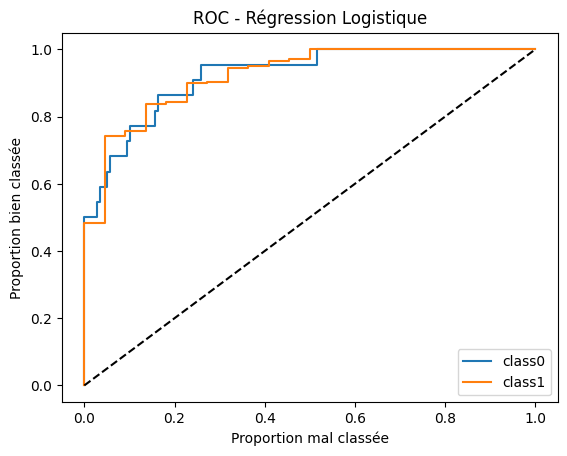

In [14]:
plt.plot(fpr0, tpr0, label="class0")
plt.plot(fpr1, tpr1, label="class1")
plt.plot([0, 1], [0, 1], color="black", linestyle="--")
plt.xlabel("Proportion mal classée")
plt.ylabel("Proportion bien classée")
plt.title("ROC - Régression Logistique")
plt.legend(loc="lower right")
plt.show()

La courbe ROC montre la performance du modèle à différents seuils de décision. Plus la courbe est proche du coin haut-gauche, mieux c'est. La diagonale en pointillés représente un modèle aléatoire — donc plus on s'en éloigne vers le haut, plus le modèle est bon. C'est le même type de graphique qu'on a vu dans le TP-Arbre pour le decision tree.

## Section 5 — Modèle 2 : KNN (K Plus Proches Voisins)

In [17]:
pipe_knn = Pipeline(steps=[("model", KNeighborsClassifier())])

In [18]:
param_grid_knn = {"model__n_neighbors": np.arange(1, 11)}

In [19]:
grid_knn = GridSearchCV(pipe_knn, param_grid=param_grid_knn, cv=5)
grid_knn.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...lassifier())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__n_neighbors': array([ 1, 2..., 8, 9, 10])}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the 

In [20]:
print("Meilleurs paramètres : ", grid_knn.best_params_)
print("Meilleur CV score : ", grid_knn.best_score_)

Meilleurs paramètres :  {'model__n_neighbors': np.int64(7)}
Meilleur CV score :  0.9279971988795518


J'ai testé KNN avec n_neighbors de 1 à 10, comme dans le TP1 où on faisait pareil sur le dataset Wine. Le GridSearchCV va trouver le meilleur k.

In [21]:
knn_optimal = grid_knn.best_estimator_
y_pred_knn = knn_optimal.predict(X_test)

In [22]:
print("Accuracy = ", accuracy_score(y_test, y_pred_knn))
print("Precision = ", precision_score(y_test, y_pred_knn))
print("Recall = ", recall_score(y_test, y_pred_knn))
print("F1-Score = ", f1_score(y_test, y_pred_knn))

Accuracy =  0.93
Precision =  0.9456521739130435
Recall =  0.9775280898876404
F1-Score =  0.9613259668508287


On compare avec la régression logistique pour voir si KNN fait mieux ou moins bien. Le déséquilibre des classes peut être un peu plus dur pour KNN parce qu'il regarde juste les voisins, donc dans une zone très majoritairement "faux", il aura tendance à prédire "faux".

## Section 6 — Courbe ROC pour KNN

In [ ]:
y_proba_knn = knn_optimal.predict_proba(X_test)
fpr0_knn, tpr0_knn, th0_knn = roc_curve(y_test==0, y_proba_knn[:, 0])
fpr1_knn, tpr1_knn, th1_knn = roc_curve(y_test==1, y_proba_knn[:, 1])

In [ ]:
plt.plot(fpr0_knn, tpr0_knn, label="class0")
plt.plot(fpr1_knn, tpr1_knn, label="class1")
plt.plot([0, 1], [0, 1], color="black", linestyle="--")
plt.xlabel("Proportion mal classée")
plt.ylabel("Proportion bien classée")
plt.title("ROC - KNN")
plt.legend(loc="lower right")
plt.show()

## Section 7 — Modèle 3 : Decision Tree

In [25]:
pipe_dt = Pipeline(steps=[("model", DecisionTreeClassifier())])

In [26]:
param_grid_dt = {"model__max_depth": [10, 15, 20], "model__min_samples_leaf": np.arange(1, 4)}

In [27]:
grid_dt = GridSearchCV(pipe_dt, param_grid=param_grid_dt, cv=5)
grid_dt.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...lassifier())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__max_depth': [10, 15, ...], 'model__min_samples_leaf': array([1, 2, 3])}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score 

In [28]:
print("Meilleurs paramètres : ", grid_dt.best_params_)
print("Meilleur CV score : ", grid_dt.best_score_)

Meilleurs paramètres :  {'model__max_depth': 10, 'model__min_samples_leaf': np.int64(1)}
Meilleur CV score :  0.9095378151260505


J'ai utilisé exactement les mêmes hyperparamètres que dans le TP-Arbre : max_depth dans [10, 15, 20] et min_samples_leaf de 1 à 3. C'est ce que faisait Hela MAROUANE.


In [30]:
dt_optimal = grid_dt.best_estimator_
y_pred_dt = dt_optimal.predict(X_test)

In [31]:
print("Accuracy = ", accuracy_score(y_test, y_pred_dt))
print("Precision = ", precision_score(y_test, y_pred_dt))
print("Recall = ", recall_score(y_test, y_pred_dt))
print("F1-Score = ", f1_score(y_test, y_pred_dt))

Accuracy =  0.915
Precision =  0.9497206703910615
Recall =  0.9550561797752809
F1-Score =  0.9523809523809523


Les arbres de décision peuvent sur-apprendre facilement, surtout si on les laisse trop profonds. Le GridSearchCV va trouver un compromis entre profondeur et capacité de généralisation.

## Section 8 — Courbe ROC pour Decision Tree

In [ ]:
y_proba_dt = dt_optimal.predict_proba(X_test)
fpr0_dt, tpr0_dt, th0_dt = roc_curve(y_test==0, y_proba_dt[:, 0])
fpr1_dt, tpr1_dt, th1_dt = roc_curve(y_test==1, y_proba_dt[:, 1])

In [ ]:
plt.plot(fpr0_dt, tpr0_dt, label="class0")
plt.plot(fpr1_dt, tpr1_dt, label="class1")
plt.plot([0, 1], [0, 1], color="black", linestyle="--")
plt.xlabel("Proportion mal classée")
plt.ylabel("Proportion bien classée")
plt.title("ROC - Decision Tree")
plt.legend(loc="lower right")
plt.show()

## Section 9 — Modèle 4 : Random Forest

In [39]:
pipe_rf = Pipeline(steps=[("model", RandomForestClassifier(random_state=42))])

In [40]:
param_grid_rf = {"model__n_estimators": [50, 100, 200], "model__max_depth": [10, 15, 20]}

In [41]:
grid_rf = GridSearchCV(pipe_rf, param_grid=param_grid_rf, cv=5)
grid_rf.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__max_depth': [10, 15, ...], 'model__n_estimators': [50, 100, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is als

In [42]:
print("Meilleurs paramètres : ", grid_rf.best_params_)
print("Meilleur CV score : ", grid_rf.best_score_)

Meilleurs paramètres :  {'model__max_depth': 15, 'model__n_estimators': 200}
Meilleur CV score :  0.9414005602240897


Random Forest c'est un modèle ensembliste basé sur le bagging d'arbres de décision (vu dans le chap 4). J'ai mis un random_state=42 pour la reproductibilité, et je teste plusieurs nombres d'arbres (n_estimators) et plusieurs profondeurs (max_depth).

In [46]:
rf_optimal = grid_rf.best_estimator_
y_pred_rf = rf_optimal.predict(X_test)

In [45]:
print("Accuracy = ", accuracy_score(y_test, y_pred_rf))
print("Precision = ", precision_score(y_test, y_pred_rf))
print("Recall = ", recall_score(y_test, y_pred_rf))
print("F1-Score = ", f1_score(y_test, y_pred_rf))

Accuracy =  0.955
Precision =  0.9567567567567568
Recall =  0.9943820224719101
F1-Score =  0.9752066115702479


## Section 10 — Courbe ROC pour Random Forest

In [47]:
y_proba_rf = rf_optimal.predict_proba(X_test)
fpr0_rf, tpr0_rf, th0_rf = roc_curve(y_test==0, y_proba_rf[:, 0])
fpr1_rf, tpr1_rf, th1_rf = roc_curve(y_test==1, y_proba_rf[:, 1])

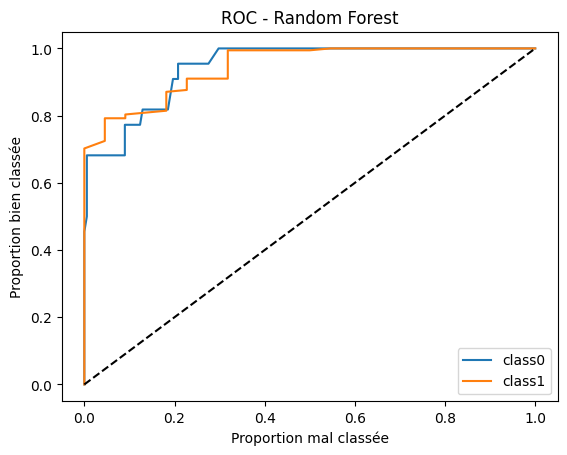

In [48]:
plt.plot(fpr0_rf, tpr0_rf, label="class0")
plt.plot(fpr1_rf, tpr1_rf, label="class1")
plt.plot([0, 1], [0, 1], color="black", linestyle="--")
plt.xlabel("Proportion mal classée")
plt.ylabel("Proportion bien classée")
plt.title("ROC - Random Forest")
plt.legend(loc="lower right")
plt.show()

## Section 11 — Modèle 5 : Bagging

In [49]:
pipe_bg = Pipeline(steps=[("model", BaggingClassifier(random_state=42))])

In [50]:
param_grid_bg = {"model__n_estimators": [50, 60, 70]}

In [51]:
grid_bg = GridSearchCV(pipe_bg, param_grid=param_grid_bg, cv=5)
grid_bg.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__n_estimators': [50, 60, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold and cand

In [52]:
print("Meilleurs paramètres : ", grid_bg.best_params_)
print("Meilleur CV score : ", grid_bg.best_score_)

Meilleurs paramètres :  {'model__n_estimators': 50}
Meilleur CV score :  0.9330252100840337


BaggingClassifier c'est l'autre méthode de bagging vue dans le chap 4. C'est ce que faisait Hela MAROUANE dans le sanstitre4.py avec n_estimators dans [55, 60, 70]. Par défaut, BaggingClassifier utilise des arbres de décision comme estimateur de base.

In [53]:
bg_optimal = grid_bg.best_estimator_
y_pred_bg = bg_optimal.predict(X_test)

In [54]:
print("Accuracy = ", accuracy_score(y_test, y_pred_bg))
print("Precision = ", precision_score(y_test, y_pred_bg))
print("Recall = ", recall_score(y_test, y_pred_bg))
print("F1-Score = ", f1_score(y_test, y_pred_bg))

Accuracy =  0.93
Precision =  0.9505494505494505
Recall =  0.9719101123595506
F1-Score =  0.9611111111111111


## Section 12 — Courbe ROC pour Bagging

In [55]:
y_proba_bg = bg_optimal.predict_proba(X_test)
fpr0_bg, tpr0_bg, th0_bg = roc_curve(y_test==0, y_proba_bg[:, 0])
fpr1_bg, tpr1_bg, th1_bg = roc_curve(y_test==1, y_proba_bg[:, 1])

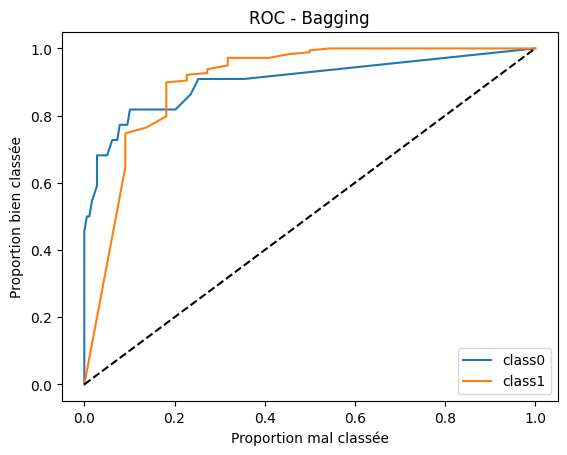

In [56]:
plt.plot(fpr0_bg, tpr0_bg, label="class0")
plt.plot(fpr1_bg, tpr1_bg, label="class1")
plt.plot([0, 1], [0, 1], color="black", linestyle="--")
plt.xlabel("Proportion mal classée")
plt.ylabel("Proportion bien classée")
plt.title("ROC - Bagging")
plt.legend(loc="lower right")
plt.show()

## Section 13 — Modèle 6 : AdaBoost

In [69]:
pipe_ada = Pipeline(steps=[("model", AdaBoostClassifier(random_state=42))])

In [70]:
param_grid_ada = {"model__n_estimators": [50, 100, 200], "model__learning_rate": [0.1, 0.5, 1.0]}

In [71]:
grid_ada = GridSearchCV(pipe_ada, param_grid=param_grid_ada, cv=5)
grid_ada.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__learning_rate': [0.1, 0.5, ...], 'model__n_estimators': [50, 100, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score 

In [74]:
print("Meilleurs paramètres : ", grid_ada.best_params_)
print("Meilleur CV score : ", grid_ada.best_score_)

Meilleurs paramètres :  {'model__learning_rate': 1.0, 'model__n_estimators': 100}
Meilleur CV score :  0.9396918767507003


AdaBoost c'est une méthode de boosting (chap 4). Contrairement au bagging qui crée des modèles en parallèle, le boosting les construit séquentiellement en se concentrant sur les erreurs des modèles précédents. Je teste plusieurs n_estimators et plusieurs learning_rate (le pas d'apprentissage).

In [67]:
ada_optimal = grid_ada.best_estimator_
y_pred_ada = ada_optimal.predict(X_test)

In [62]:
print("Accuracy = ", accuracy_score(y_test, y_pred_ada))
print("Precision = ", precision_score(y_test, y_pred_ada))
print("Recall = ", recall_score(y_test, y_pred_ada))
print("F1-Score = ", f1_score(y_test, y_pred_ada))

Accuracy =  0.95
Precision =  0.9516129032258065
Recall =  0.9943820224719101
F1-Score =  0.9725274725274725


## Section 14 — Courbe ROC pour AdaBoost

In [75]:
y_proba_ada = ada_optimal.predict_proba(X_test)
fpr0_ada, tpr0_ada, th0_ada = roc_curve(y_test==0, y_proba_ada[:, 0])
fpr1_ada, tpr1_ada, th1_ada = roc_curve(y_test==1, y_proba_ada[:, 1])

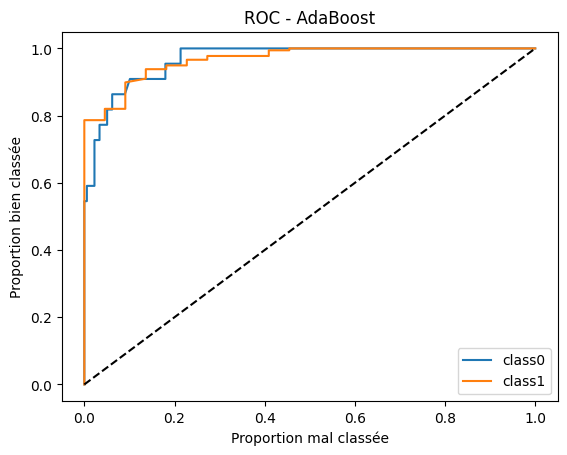

In [76]:
plt.plot(fpr0_ada, tpr0_ada, label="class0")
plt.plot(fpr1_ada, tpr1_ada, label="class1")
plt.plot([0, 1], [0, 1], color="black", linestyle="--")
plt.xlabel("Proportion mal classée")
plt.ylabel("Proportion bien classée")
plt.title("ROC - AdaBoost")
plt.legend(loc="lower right")
plt.show()

## Section 15 — Modèle 7 : Gradient Boosting

In [77]:
pipe_gb = Pipeline(steps=[("model", GradientBoostingClassifier(random_state=42))])

In [78]:
param_grid_gb = {"model__n_estimators": [50, 100], "model__learning_rate": [0.05, 0.1, 0.2], "model__max_depth": [3, 5]}

In [79]:
grid_gb = GridSearchCV(pipe_gb, param_grid=param_grid_gb, cv=5)
grid_gb.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__learning_rate': [0.05, 0.1, ...], 'model__max_depth': [3, 5], 'model__n_estimators': [50, 100]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is dis

In [80]:
print("Meilleurs paramètres : ", grid_gb.best_params_)
print("Meilleur CV score : ", grid_gb.best_score_)

Meilleurs paramètres :  {'model__learning_rate': 0.05, 'model__max_depth': 3, 'model__n_estimators': 100}
Meilleur CV score :  0.936358543417367


Gradient Boosting c'est une autre méthode de boosting du chap 4. Au lieu de pondérer les erreurs comme AdaBoost, il construit chaque arbre pour corriger l'erreur résiduelle du précédent. C'est souvent un des modèles les plus performants. Je teste plusieurs combinaisons de n_estimators, learning_rate et max_depth.

In [81]:
gb_optimal = grid_gb.best_estimator_
y_pred_gb = gb_optimal.predict(X_test)

In [82]:
print("Accuracy = ", accuracy_score(y_test, y_pred_gb))
print("Precision = ", precision_score(y_test, y_pred_gb))
print("Recall = ", recall_score(y_test, y_pred_gb))
print("F1-Score = ", f1_score(y_test, y_pred_gb))

Accuracy =  0.955
Precision =  0.9518716577540107
Recall =  1.0
F1-Score =  0.9753424657534246


## Section 16 — Courbe ROC pour Gradient Boosting

In [83]:
y_proba_gb = gb_optimal.predict_proba(X_test)
fpr0_gb, tpr0_gb, th0_gb = roc_curve(y_test==0, y_proba_gb[:, 0])
fpr1_gb, tpr1_gb, th1_gb = roc_curve(y_test==1, y_proba_gb[:, 1])

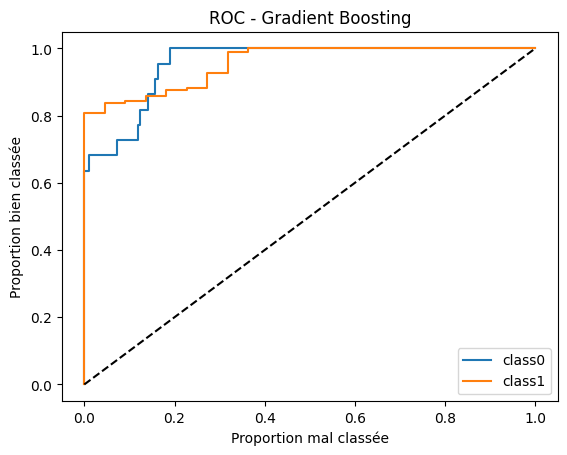

In [84]:
plt.plot(fpr0_gb, tpr0_gb, label="class0")
plt.plot(fpr1_gb, tpr1_gb, label="class1")
plt.plot([0, 1], [0, 1], color="black", linestyle="--")
plt.xlabel("Proportion mal classée")
plt.ylabel("Proportion bien classée")
plt.title("ROC - Gradient Boosting")
plt.legend(loc="lower right")
plt.show()

## Section 17 — Modèle 8 : Voting Classifier

Pour finir, j'utilise un VotingClassifier qui combine plusieurs modèles. C'est ce qu'on a vu dans le chap 4 sur les méthodes ensemblistes : au lieu de faire confiance à un seul modèle, on demande l'avis de plusieurs et on prend la décision en commun. Je vais combiner mes 3 meilleurs modèles de la Vague 3 : Random Forest, AdaBoost et Gradient Boosting. J'utilise voting="soft" pour utiliser les probabilités prédites par chaque modèle plutôt qu'un vote majoritaire simple.

In [ ]:
voting_clf = VotingClassifier(
    estimators=[
        ("rf", rf_optimal),
        ("ada", ada_optimal),
        ("gb", gb_optimal)
    ],
    voting="soft"
)

In [ ]:
voting_clf.fit(X_train, y_train)

In [ ]:
y_pred_voting = voting_clf.predict(X_test)

In [ ]:
print("Accuracy = ", accuracy_score(y_test, y_pred_voting))
print("Precision = ", precision_score(y_test, y_pred_voting))
print("Recall = ", recall_score(y_test, y_pred_voting))
print("F1-Score = ", f1_score(y_test, y_pred_voting))

On va voir si la combinaison des 3 modèles donne de meilleurs résultats que chaque modèle pris séparément. En théorie, le voting permet de réduire les erreurs de chaque modèle pris individuellement. Mais comme mes 3 modèles sont déjà très bons, l'amélioration peut être faible.

## Section 18 — Courbe ROC pour Voting Classifier

In [ ]:
y_proba_voting = voting_clf.predict_proba(X_test)
fpr0_v, tpr0_v, th0_v = roc_curve(y_test==0, y_proba_voting[:, 0])
fpr1_v, tpr1_v, th1_v = roc_curve(y_test==1, y_proba_voting[:, 1])

In [ ]:
plt.plot(fpr0_v, tpr0_v, label="class0")
plt.plot(fpr1_v, tpr1_v, label="class1")
plt.plot([0, 1], [0, 1], color="black", linestyle="--")
plt.xlabel("Proportion mal classée")
plt.ylabel("Proportion bien classée")
plt.title("ROC - Voting Classifier")
plt.legend(loc="lower right")
plt.show()